In [1]:
# Compare the evolution of energies. We saw before that this twist had a sort of "stationary" state for 25 ns.
# Nevertheless, we cannot be sure of this.

# IDEA: ADD THE READING ROUTINE TO THE LIBRARY...
import numpy as np
import matplotlib.pyplot as plt

folderdir = "mdresults/"
twists = [0, 0.01, 0.02]
n_tws = len(twists)

pots = [[] for i in range(n_tws)]
steps = [[] for i in range(n_tws)]

# Line to unpack .xvg generated by GROMACS
for i in range(n_tws):
    steps[i], pots[i] = np.loadtxt(folderdir + f"tw{twists[i]}/potential.xvg",comments=["@","#"],unpack=True)
    steps[i] = steps[i]/1000 # to ns

In [2]:
# Compute mean through timescales
ene_mean = [[] for i in range(n_tws)]
t_rep = [[] for i in range(n_tws)]
ts = 2.5 #ns, timescale

for i in range(n_tws):
    t_e = steps[i]
    ene = pots[i]
    n_m = int(t_e[-1]/ts)
    stp_nm = int((len(t_e)-1)/n_m)
    ene_mean[i] = np.zeros(n_m + 1)
    t_rep[i] = np.zeros(n_m + 1)

    ene_mean[i][0], t_rep[i][0] = ene[0], t_e[0]

    for j in range(n_m):
        ene_mean[i][j+1] = np.mean(ene[stp_nm*j:stp_nm*(j+1)])
        t_rep[i][j+1] = np.mean(t_e[stp_nm*j:stp_nm*(j+1)])

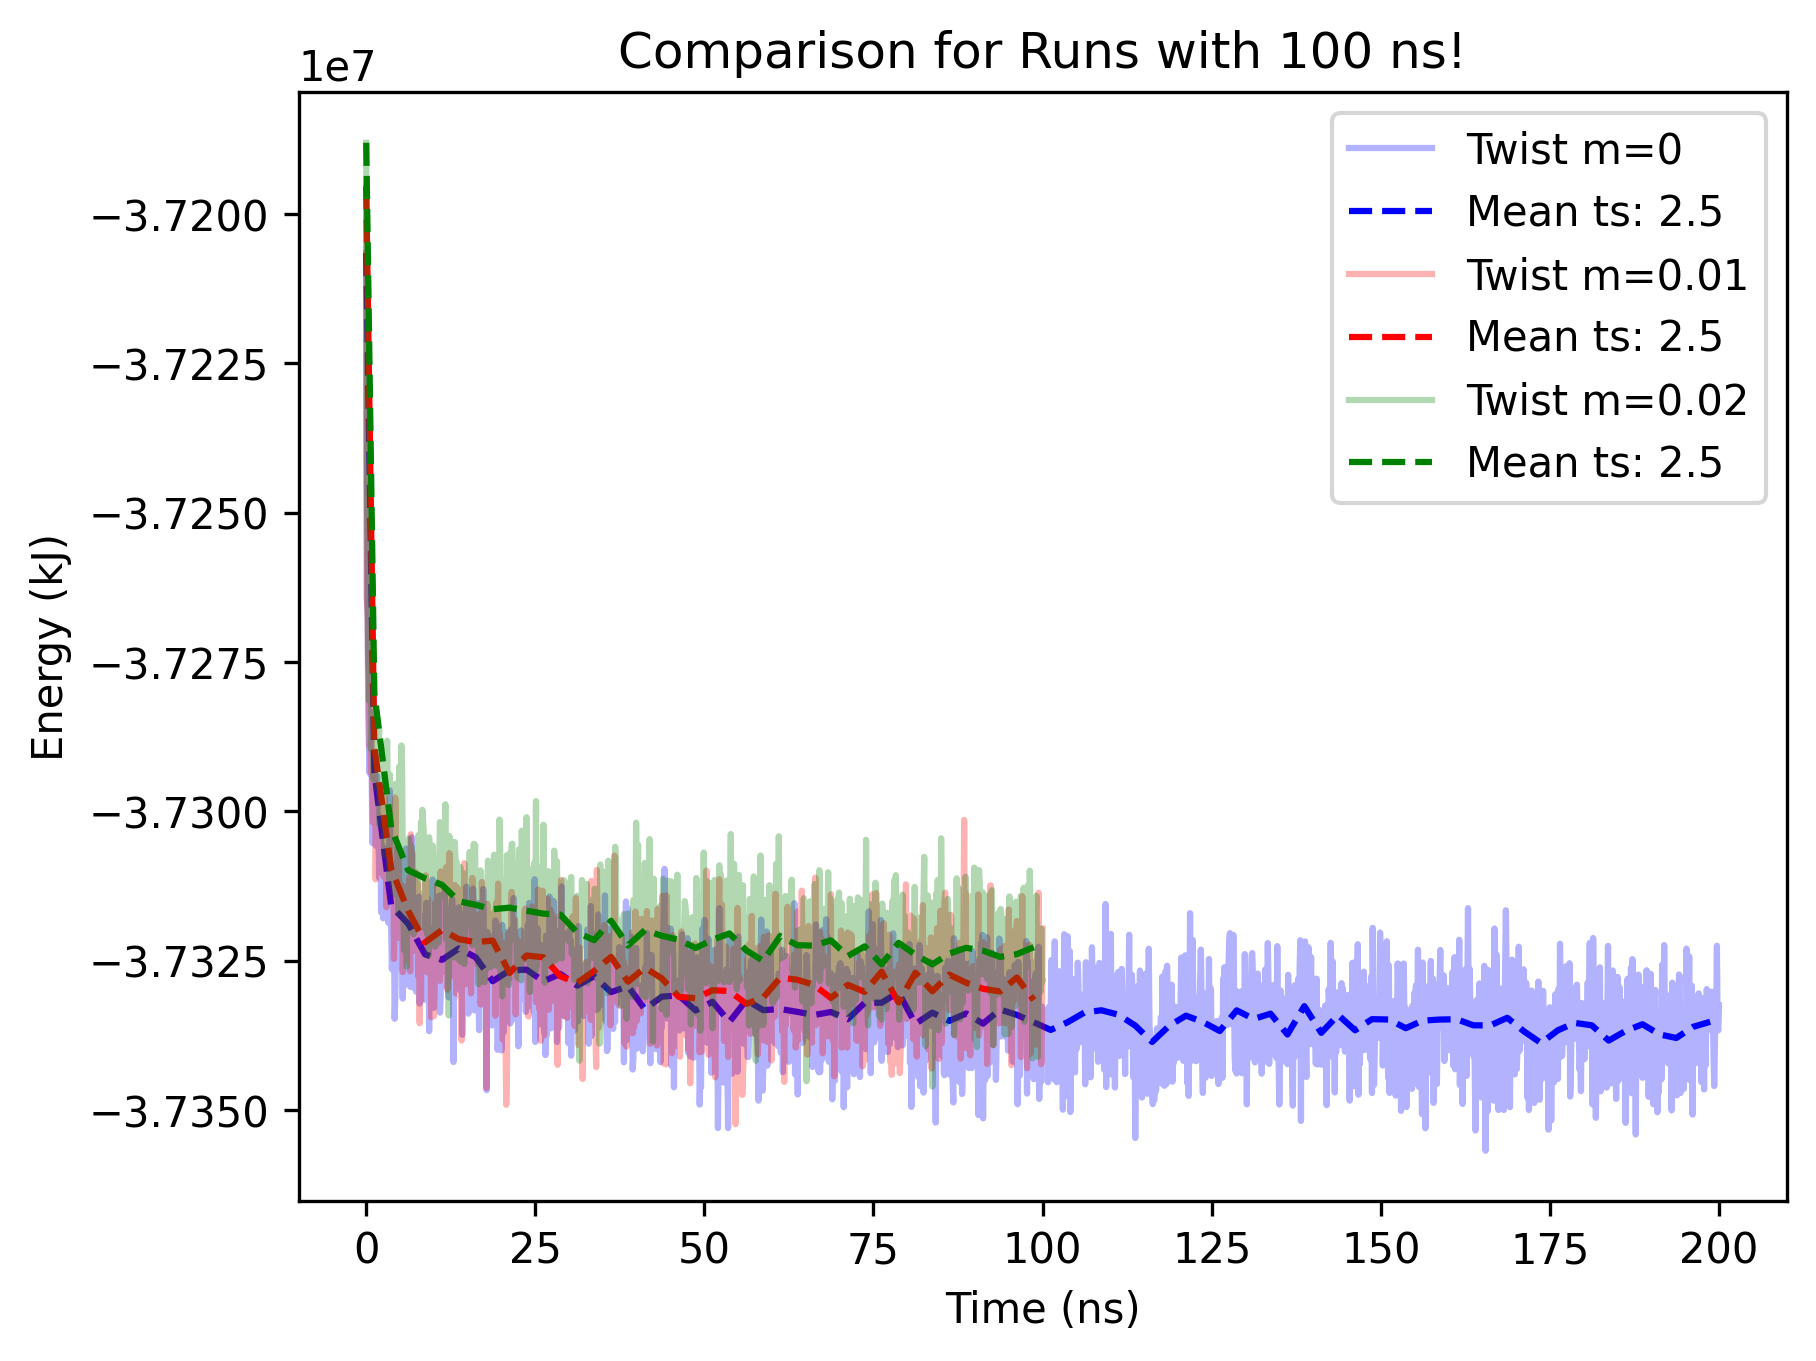

In [4]:
plt.figure(dpi=300)

colors=['b', 'r', 'g']

for i in range(n_tws):
    plt.plot(steps[i], pots[i], label=f"Twist m={twists[i]}", alpha=0.3, color=colors[i])
    plt.plot(t_rep[i], ene_mean[i], label=f"Mean ts: {ts}", linestyle="dashed", color=colors[i])

plt.xlabel("Time (ns)")
plt.ylabel("Energy (kJ)")
plt.title("Comparison for Runs with 100 ns!")

plt.legend()
plt.show()